In [1]:
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from scipy.optimize import curve_fit
import os, json

from cigar import load_waveforms_until_eof, triple_gauss, four_gauss

In [2]:
board_version = 2
if board_version == 1:
    amplified_offsets = [550, 600, 550, 600]
elif board_version == 2:
    # amplified_offsets = [600,600,600,600]
    amplified_offsets = [572.65, 589.88, 589.06, 549.06]


/var/folders/3c/lhfrz7cs27x5vh_1y0ytw77r0000gn/T/ipykernel_20861/2825514638.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  charge = np.trapz(wfs[:, 0, charge_slice] + amplified_offsets[i], axis=1)


Text(0.5, 0.98, '/Users/roberto/cigar/xe/alpha/85_bar, Run 65')

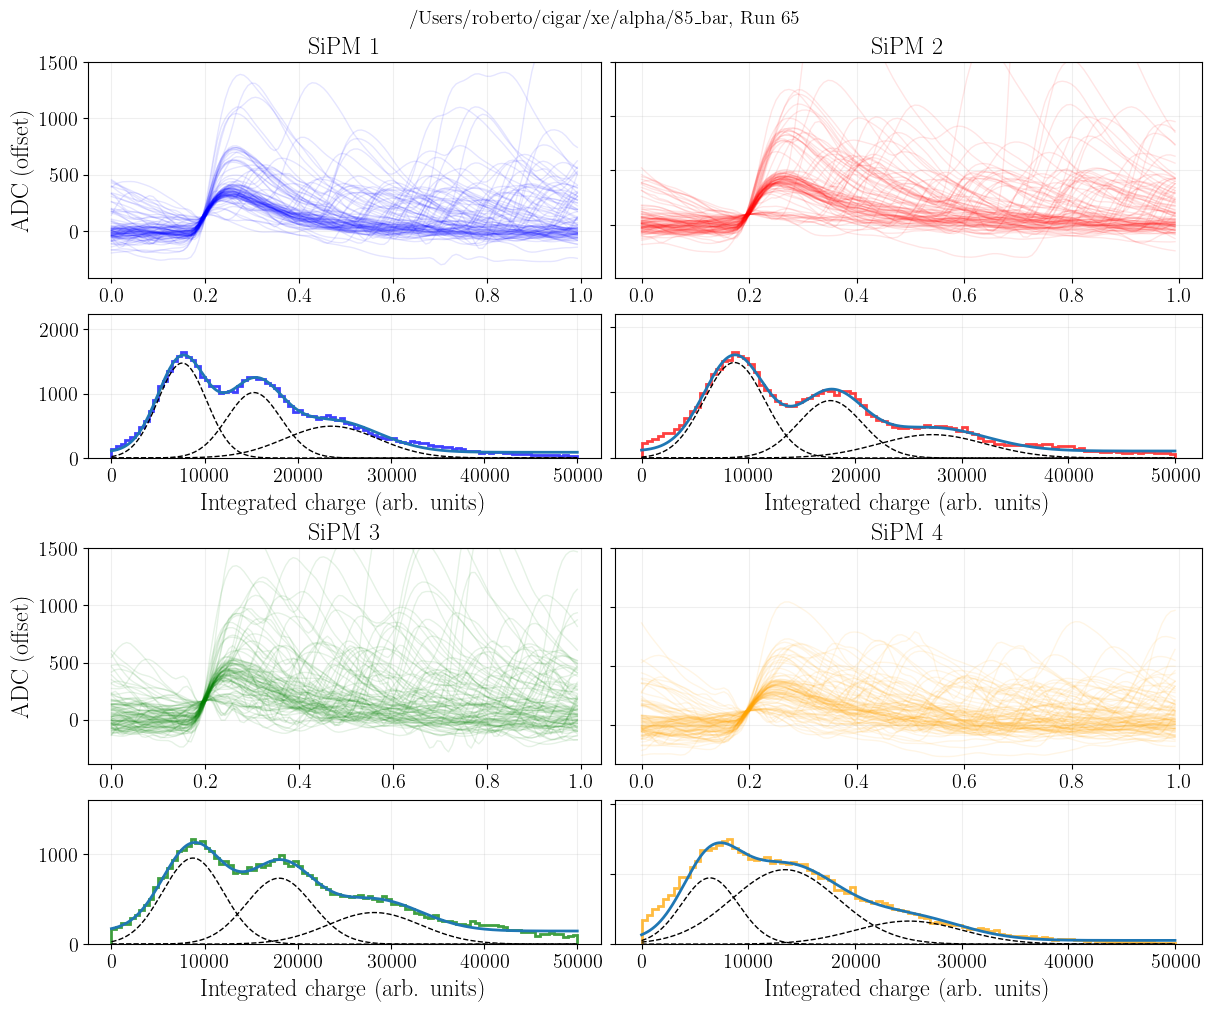

In [12]:

# Config
# --------------------
channels = [1, 2, 3, 4]
colors   = ['blue', 'red', 'green', 'orange']
pressure = 8.5
base     = f"/Users/roberto/cigar/xe/alpha/{str(pressure).replace('.', '')}_bar"
pressures_run = {8.5: 65, 6.5: 91, 5.5: 84, 4.5: 81, 3.5: 84, 2.5: 109, 1.5: 115}
pressures_run_ar = {8.5: 118, 7.5: 124, 6.5: 128, 5.5: 131}
pressures_run_ar = {8.5: 118, 7.5: 174, 6.5: 176, 5.5: 178, 4.5: 180, 3.5: 182, 2.5: 184, 1.5: 186}


run      = pressures_run[pressure]  # bar
offset   = 600
charge_slice = slice(20, 100)   # integrate samples 20:100
bins     = 100
charge_range = (0, 50000)

fig = plt.figure(figsize=(12, 10), constrained_layout=True)
outer = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.2)
peak_means = {}      # ch -> np.array([mu1, mu2, mu3])
peak_as = {}        # ch -> np.array([A1, A2, A3])
peak_errors = {}
time_ticks = np.linspace(0, 124*8, 124)/1e3  # 124 samples * 8 ns/sample = 992 ns total

for i, (ch, color) in enumerate(zip(channels, colors)):
    # Load waveforms for this channel
    files = glob(f"{base}/Run{run}SPheCH{ch}/*.bin")
    wfs_list = [load_waveforms_until_eof(f, channels=1, samples_per_waveform=124, event_header_bytes=28)[0]
                for f in files]
    times_list = [load_waveforms_until_eof(f, channels=1, samples_per_waveform=124, event_header_bytes=28)[1]
                  for f in files]
    times = np.concatenate(times_list, axis=0)
    wfs = np.concatenate(wfs_list, axis=0)  # shape: (N, 1, 124)
    mask = np.min(wfs, axis=(1, 2)) > -900 # Peltier noise filter
    wfs = wfs[mask]
    # Subgrid: independent x-axes (do NOT share x between top and bottom)
    r, c = divmod(i, 2)
    sub = outer[r, c].subgridspec(2, 1, height_ratios=[3, 2], hspace=0.)
    ax_top = fig.add_subplot(sub[0])
    ax_bot = fig.add_subplot(sub[1])
    if c == 1:
        ax_top.tick_params(labelleft=False)
        ax_bot.tick_params(labelleft=False)

    amplified_offsets[i] = -np.median(wfs[:,0,:20])

    # ---- Top: waveforms ----
    nshow = min(100, len(wfs))
    for j in range(nshow):
        ax_top.plot(time_ticks, wfs[j, 0] + amplified_offsets[i], color=color, alpha=0.1, linewidth=1)
    ax_top.set_title(f"SiPM {ch}")
    if c == 0:
        ax_top.set_ylabel("ADC (offset)")
    ax_top.grid(alpha=0.2)

    # ---- Bottom: charge spectrum + triple-Gaussian fit ----
    charge = np.trapz(wfs[:, 0, charge_slice] + amplified_offsets[i], axis=1)

    counts, edges = np.histogram(charge, bins=bins, range=charge_range)
    centers = 0.5 * (edges[:-1] + edges[1:])  # Correctly compute bin centers
    ax_bot.hist(charge, bins=bins, range=charge_range, color=color, alpha=0.75, label="Data", histtype='step', lw=2)
    # ax_bot.set_ylabel("Counts")
    ax_bot.set_xlabel("Integrated charge (arb. units)")
    ax_bot.grid(alpha=0.2)
    ax_top.set_ylim(top=1500)

    # Initial guesses and bounds for the three peaks
    # Seed near ~10k, ~17k, and ~24k (adjustable); widths ~800; amplitudes ~max count.
    A_guess = max(counts) if len(counts) else 100.0
    p0 = [
        0.8*A_guess, 10000.0, 800.0,
        0.6*A_guess, 17000.0, 900.0,
        0.4*A_guess, 24000.0, 1000.0,
        # 0.2*A_guess, 45500.0, 1000.0,
        0.0  # constant baseline
    ]
    # Reasonable bounds to stabilize the fit

    lower = [
        0.0,  7000.0,  200.0,
        0.0, 13000.0,  200.0,
        0.0, 20000.0,  200.0,
        # 0.0, 32000.0,  200.0,
        -np.inf
    ]

    # if ch == 2:
    #     p0 = [
    #         0.8*A_guess, 11000.0, 800.0,
    #         0.6*A_guess, 21000.0, 900.0,
    #         0.4*A_guess, 32000.0, 1000.0,
    #         0.01  # constant baseline
    #     ]
    #     lower = [
    #         0.1*A_guess, 9000.0, 700.0,
    #         0.1*A_guess, 16000.0, 800.0,
    #         0.1*A_guess, 29000.0, 900.0,
    #         0.0  # constant baseline
    #     ]
    # if ch == 3:
    #     p0 = [
    #         0.8*A_guess, 6100.0, 3400.0,
    #         0.6*A_guess, 18600.0, 3400.0,
    #         0.4*A_guess, 30600.0, 3400.0,
    #         # 0.2*A_guess, 37000.0, 3400.0,
    #         0.01  # constant baseline
    #     ]
    #     lower = [
    #         0.1*A_guess, 6000.0, 2300.0,
    #         0.1*A_guess, 12000.0, 2300.0,
    #         0.1*A_guess, 20200.0, 2300.0,
    #         # 0.1*A_guess, 36000.0, 2300.0,
    #         0.0  # constant baseline
    #     ]
    upper = [
        np.inf, 15000.0, 5000.0,
        np.inf, 30000.0, 5000.0,
        np.inf, 40000.0, 5000.0,
        # np.inf, 60000.0, 5000.0,
        np.inf
    ]
    if ch == 4:
        p0 = [
            0.8*A_guess, 11000.0, 800.0,
            0.6*A_guess, 19000.0, 900.0,
            0.4*A_guess, 28000.0, 1100.0,
            # 0.2*A_guess, 45500.0, 1000.0,
            0.0  # constant baseline
        ]
        lower = [
            0.0,  5000.0,  200.0,
            0.0, 12000.0,  200.0,
            0.0, 20000.0,  1000.0,
            -np.inf
        ]

    # Fit
    try:
        popt, pcov = curve_fit(triple_gauss, centers[centers>5000], counts[centers>5000], p0=p0, bounds=(lower, upper), maxfev=20000)
        fit_x = np.linspace(charge_range[0], charge_range[1], 2000)
        fit_y = triple_gauss(fit_x, *popt)
        ax_bot.plot(fit_x, fit_y, linewidth=2, label="3-Gauss fit")

        # Plot individual Gaussians for clarity
        A1, mu1, s1, A2, mu2, s2, A3, mu3, s3, c = popt
        g1 = A1 * np.exp(-0.5*((fit_x - mu1)/s1)**2) + 0.0
        g2 = A2 * np.exp(-0.5*((fit_x - mu2)/s2)**2) + 0.0
        g3 = A3 * np.exp(-0.5*((fit_x - mu3)/s3)**2) + 0.0
        # g4 = A4 * np.exp(-0.5*((fit_x - mu4)/s4)**2) + 0.0
        ax_bot.plot(fit_x, g1, linestyle="--", linewidth=1, c='k')
        ax_bot.plot(fit_x, g2, linestyle="--", linewidth=1, c='k')
        ax_bot.plot(fit_x, g3, linestyle="--", linewidth=1, c='k')
        # ax_bot.plot(fit_x, g4, linestyle="--", linewidth=1, c='k')
        perr = np.sqrt(np.diag(pcov))
        mu1_err, mu2_err, mu3_err = perr[1], perr[4], perr[7]
        # Annotate the peak positions
        # ax_bot.annotate(fr"$\mu_1 = {mu1:.0f}$", xy=(mu1, four_gauss(mu1, *popt)), xytext=(mu1, ax_bot.get_ylim()[1]*1.1),
        #                 arrowprops=dict(arrowstyle='->', lw=1), ha='center')
        # ax_bot.annotate(fr"$\mu_2 = {mu2:.0f}$", xy=(mu2, four_gauss(mu2, *popt)), xytext=(mu2, ax_bot.get_ylim()[1]*0.75),
        #                 arrowprops=dict(arrowstyle='->', lw=1), ha='center')
        # ax_bot.annotate(fr"$\mu_3 = {mu3:.0f}$", xy=(mu3, four_gauss(mu3, *popt)), xytext=(mu3, ax_bot.get_ylim()[1]*0.5),
        #                 arrowprops=dict(arrowstyle='->', lw=1), ha='center')
        # ax_bot.annotate(fr"$\mu_4 = {mu4:.0f}$", xy=(mu4, four_gauss(mu4, *popt)), xytext=(mu4, ax_bot.get_ylim()[1]*0.3),
        #                 arrowprops=dict(arrowstyle='->', lw=1), ha='center')

        ax_bot.set_ylim(top=ax_bot.get_ylim()[1]*1.3)  # Add some headroom for annotations
        peak_as[ch] = np.array([A1, A2, A3])
        peak_means[ch]  = np.array([mu1, mu2, mu3])
        peak_errors[ch] = np.array([mu1_err, mu2_err, mu3_err])
        # ax_bot.legend(loc="upper right", fontsize=8)
    except Exception as e:
        # If the fit fails, keep the histogram and note it
        ax_bot.text(0.02, 0.95, f"Fit failed: {e}", transform=ax_bot.transAxes, va='top', ha='left', fontsize=8)



fig.suptitle(f"{base}, Run {run}", fontsize=14)